# Graded Response Model — TMA (Single Scale)

Fits a single-dimensional GRM to all 50 TMA items. With binary responses (K=2), this is equivalent to a 2PL IRT model.

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
os.environ['JAX_PLATFORMS'] = 'cpu'
sys.path.insert(0, os.path.dirname(os.getcwd()))

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from plot_helpers import (plot_loss_comparison, plot_forest_discriminations,
                          plot_ability_scatter, plot_ability_distributions,
                          plot_thresholds, plot_individual_abilities,
                          plot_imputation_weights_pcolormesh)

## 1. Load Data

In [2]:
from bayesianquilts.data.tma import get_data, item_keys, response_cardinality

df, num_people = get_data(polars_out=True)
print(f"Dataset shape: {df.shape}")
print(f"Number of people: {num_people}")
print(f"Number of items: {len(item_keys)}")
print(f"Response cardinality: {response_cardinality} (binary: 0=False, 1=True)")
df.head()

Dataset shape: (5410, 51)
Number of people: 5410
Number of items: 50
Response cardinality: 2 (binary: 0=False, 1=True)


person,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20,Q21,Q22,Q23,Q24,Q25,Q26,Q27,Q28,Q29,Q30,Q31,Q32,Q33,Q34,Q35,Q36,Q37,Q38,Q39,Q40,Q41,Q42,Q43,Q44,Q45,Q46,Q47,Q48,Q49,Q50
u32,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
0,1,1,1,0,1,0,1,1,0,1,0,0,1,1,1,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,1
1,0,1,0,0,1,0,0,1,0,1,0,0,1,1,1,1,0,0,1,1,1,1,0,0,0,0,1,0,0,1,1,0,1,1,0,1,0,1,1,1,0,0,1,1,1,1,1,1,1,1
2,1,0,0,1,0,0,0,0,0,0,0,1,0,1,0,1,0,1,1,1,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,1
3,0,1,1,0,0,0,0,1,1,1,0,1,1,1,0,0,1,0,1,0,1,0,0,1,0,0,0,0,1,1,1,1,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,1
4,0,1,1,0,0,1,0,0,0,0,0,1,1,1,0,0,0,1,1,1,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1


In [3]:
SUBSAMPLE_N = num_people
sub_df = df
print(f"Using full dataset: N = {SUBSAMPLE_N}")

Using full dataset: N = 5410


## 2. Prepare Data

In [4]:
def make_data_dict(dataframe):
    data = {}
    for col in dataframe.columns:
        arr = dataframe[col].to_numpy().astype(np.float64)
        data[col] = arr
    data['person'] = np.arange(len(dataframe), dtype=np.float64)
    return data

batch = make_data_dict(sub_df)

# Check for missing/invalid values
n_bad = sum(
    np.sum(np.isnan(batch[k]) | (batch[k] < 0) | (batch[k] >= response_cardinality))
    for k in item_keys
)
print(f"Bad/missing values: {n_bad}")

BATCH_SIZE = 256
steps_per_epoch = int(np.ceil(SUBSAMPLE_N / BATCH_SIZE))
print(f"N: {SUBSAMPLE_N}, Batch size: {BATCH_SIZE}, Steps per epoch: {steps_per_epoch}")

def data_factory():
    indices = np.arange(SUBSAMPLE_N)
    np.random.shuffle(indices)
    for start in range(0, SUBSAMPLE_N, BATCH_SIZE):
        end = min(start + BATCH_SIZE, SUBSAMPLE_N)
        idx_batch = indices[start:end]
        yield {k: v[idx_batch] for k, v in batch.items()}

Bad/missing values: 2612
N: 5410, Batch size: 256, Steps per epoch: 22


## 3. Fit Baseline GRM (Ignorable Missingness)

In [5]:
from bayesianquilts.irt.grm import GRModel

model_baseline = GRModel(
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    dim=1,
    kappa_scale=0.1,
    response_cardinality=response_cardinality,
    dtype=jnp.float64,
)

NUM_EPOCHS = 200
SNAPSHOT_EPOCH = 50

res_baseline = model_baseline.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=2e-4,
    patience=10,
    zero_nan_grads=True,
    snapshot_epoch=SNAPSHOT_EPOCH,
    lr_decay_factor=0.975,
)

losses_baseline = res_baseline[0]
snapshot_params = res_baseline[2] if len(res_baseline) > 2 else None
print(f"Baseline final loss: {losses_baseline[-1]:.2f}")
if snapshot_params is not None:
    print(f"Snapshot saved at epoch {SNAPSHOT_EPOCH}")

--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.975
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'eta\\softplus\\normal\\loc', 'eta\\softplus\\normal\\scale', 'kappa\\softplus\\igamma\\concentration', 'kappa\\softplus\\igamma\\scale', 'kappa_a\\softplus\\igamma\\concentration', 'kappa_a\\softplus\\igamma\\scale', 'abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000200):   0%|          | 0/22 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000200):   0%|          | 0/22 [00:02<?, ?batch/s, best_loss=inf, loss=9903.4315]

Epoch 1/200 (LR: 0.000200):   5%|▍         | 1/22 [00:02<00:51,  2.46s/batch, best_loss=inf, loss=9903.4315]

Epoch 1/200 (LR: 0.000200):   5%|▍         | 1/22 [00:02<00:51,  2.46s/batch, best_loss=inf, loss=9877.3260]

...

Epoch 200/200 (LR: 0.000200):   0%|          | 0/22 [00:00<?, ?batch/s, best_loss=7423.9705, loss=7631.2817]

Epoch 200/200 (LR: 0.000200):   0%|          | 0/22 [00:00<?, ?batch/s, best_loss=7423.9705, loss=7650.0535]

Epoch 200/200 (LR: 0.000200):  95%|█████████▌| 21/22 [00:00<00:00, 205.31batch/s, best_loss=7423.9705, loss=7650.0535]

Epoch 200/200 (LR: 0.000200):  95%|█████████▌| 21/22 [00:00<00:00, 205.31batch/s, best_loss=7423.9705, loss=1175.4842]

  -> New best loss found. Checkpoint saved.                    

--- Training Finished ---
Baseline final loss: 7420.85
Snapshot saved at epoch 50


In [6]:
model_baseline.save_to_disk('grm_baseline')

In [7]:
# Calibrate baseline model early so we can compute WAIC for mixed imputation
def calibrate_manually(model, n_samples=32, seed=42):
    try:
        surrogate = model.surrogate_distribution_generator(model.params)
        key = jax.random.PRNGKey(seed)
        samples = surrogate.sample(n_samples, seed=key)
        expectations = {k: jnp.mean(v, axis=0) for k, v in samples.items()}
        model.calibrated_expectations = expectations
        model.surrogate_sample = samples
    except KeyError as e:
        print(f"  Warning: surrogate sampling failed ({e}), using point estimates")
        point_estimates = {}
        for key_name, value in model.params.items():
            parts = key_name.split('\\')
            if len(parts) >= 4:
                param_name = parts[0]
                if parts[-2] == 'normal' and parts[-1] == 'loc':
                    point_estimates[param_name] = value
        model.calibrated_expectations = point_estimates

calibrate_manually(model_baseline, n_samples=32, seed=101)

## 4. Fit MICEBayesianLOO Imputation Model

In [8]:
from bayesianquilts.imputation.mice_loo import MICEBayesianLOO

# Convert to pandas with NaN for missing values (-1 marks missing in TMA)
imputation_df = sub_df.select(item_keys).to_pandas()
imputation_df = imputation_df.replace(-1, np.nan)
print(f"Imputation DataFrame shape: {imputation_df.shape}")
print(f"NaN count: {imputation_df.isna().sum().sum()}")

mice_loo = MICEBayesianLOO(
    random_state=42,
    prior_scale=1.0,
    pathfinder_num_samples=100,
    pathfinder_maxiter=50,
    batch_size=512,
    verbose=True,
)

mice_loo.fit_loo_models(
    X_df=imputation_df,
    n_top_features=50,
    n_jobs=1,
    fit_zero_predictors=True,
    seed=42,
)

print(f"\nFitted variable names: {mice_loo.variable_names[:5]}...")
print(f"Zero-predictor models: {len(mice_loo.zero_predictor_results)}")
print(f"Univariate models: {len(mice_loo.univariate_results)}")

Imputation DataFrame shape: (5410, 50)


NaN count: 2612
Computing feature correlations...
Fitting MICE Bayesian LOO-CV models with Pathfinder
  Variables: 50
  Observations: 5410
  Min obs per model: 5
  Parallel jobs: 1
  Top features per target: 50

Fitting zero-predictor models...
  Scheduling 50 zero-predictor jobs...


  Var 0 (Q1): n_obs=5379, elpd/n=-0.0643


  Var 1 (Q2): n_obs=5368, elpd/n=-0.0644


  Var 2 (Q3): n_obs=5378, elpd/n=-0.0578


...

  Processing Q47 (49 valid predictors)


  Processing Q48 (49 valid predictors)


  Processing Q49 (49 valid predictors)


  Processing Q50 (49 valid predictors)



Fitted variable names: ['Q1', 'Q2', 'Q3', 'Q4', 'Q5']...
Zero-predictor models: 50
Univariate models: 2450


In [9]:
mice_loo.save('mice_loo_model.yaml')

In [10]:
from bayesianquilts.imputation.mixed import IrtMixedImputationModel

mixed_imputation = IrtMixedImputationModel(
    irt_model=model_baseline,
    mice_model=mice_loo,
    data_factory=data_factory,
    irt_elpd_batch_size=4,
)

print(mixed_imputation.summary())

Item Weights (MICE vs IRT):
Item           w_mice  ELPD_mice   ELPD_irt
--------------------------------------------
Q1              0.648    -0.0570    -0.6678
Q2              0.646    -0.0601    -0.6622
Q3              0.644    -0.0546    -0.6489
Q4              0.653    -0.0624    -0.6933
Q5              0.640    -0.0563    -0.6335
Q6              0.618    -0.0351    -0.5155
Q7              0.634    -0.0452    -0.5936
Q8              0.647    -0.0605    -0.6679
Q9              0.653    -0.0618    -0.6927
Q10             0.652    -0.0612    -0.6894
Q11             0.599    -0.0315    -0.4322
Q12             0.651    -0.0573    -0.6802
Q13             0.637    -0.0509    -0.6143
Q14             0.643    -0.0531    -0.6410
Q15             0.651    -0.0643    -0.6875
Q16             0.652    -0.0600    -0.6873
Q17             0.646    -0.0554    -0.6584
Q18             0.638    -0.0494    -0.6142
Q19             0.652    -0.0630    -0.6923
Q20             0.652    -0.0635    -0.6898
Q21

## 5. Fit GRM with Analytic Rao-Blackwellized Imputation

In [11]:
model_imputed = GRModel(
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    dim=1,
    kappa_scale=0.1,
    response_cardinality=response_cardinality,
    dtype=jnp.float64,
    imputation_model=mixed_imputation,
)

if snapshot_params is not None:
    print(f"Warm-starting from baseline epoch-{SNAPSHOT_EPOCH} snapshot")

res_imputed = model_imputed.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=2e-4,
    patience=10,
    zero_nan_grads=True,
    initial_values=snapshot_params,
    lr_decay_factor=0.975,
)

losses_imputed = res_imputed[0]
print(f"Imputed final loss: {losses_imputed[-1]:.2f}")

Warm-starting from baseline epoch-50 snapshot
--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.975
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'eta\\softplus\\normal\\loc', 'eta\\softplus\\normal\\scale', 'kappa\\softplus\\igamma\\concentration', 'kappa\\softplus\\igamma\\scale', 'kappa_a\\softplus\\igamma\\concentration', 'kappa_a\\softplus\\igamma\\scale', 'mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000200):   0%|          | 0/22 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000200):   0%|          | 0/22 [00:02<?, ?batch/s, best_loss=inf, loss=9083.4181]

Epoch 1/200 (LR: 0.000200):   5%|▍         | 1/22 [00:02<00:50,  2.39s/batch, best_loss=inf, loss=9083.4181]

Epoch 1/200 (LR: 0.000200):   5%|▍         | 1/22 [00:02<00:50,  2.39s/batch, best_loss=inf, loss=9102.1578]

...

Epoch 200/200 (LR: 0.000200):  68%|██████▊   | 15/22 [00:00<00:00, 42.61batch/s, best_loss=7400.5853, loss=7707.1920]

Epoch 200/200 (LR: 0.000200):  91%|█████████ | 20/22 [00:00<00:00, 41.84batch/s, best_loss=7400.5853, loss=7707.1920]

Epoch 200/200 (LR: 0.000200):  91%|█████████ | 20/22 [00:00<00:00, 41.84batch/s, best_loss=7400.5853, loss=7615.6244]

Epoch 200/200 (LR: 0.000200):  91%|█████████ | 20/22 [00:00<00:00, 41.84batch/s, best_loss=7400.5853, loss=1235.0216]

  -> New best loss found. Checkpoint saved.                    

--- Training Finished ---
Imputed final loss: 7398.11


In [12]:
model_imputed.save_to_disk('grm_imputed')

## 6. Compare Results

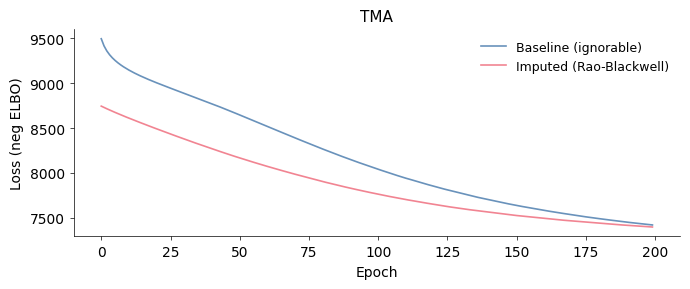

In [13]:
fig = plot_loss_comparison(losses_baseline, losses_imputed, title='TMA')
fig.savefig('loss_comparison.pdf', bbox_inches='tight', dpi=150)
plt.show()

In [14]:
# calibrate_manually already defined above; just calibrate the imputed model
calibrate_manually(model_imputed, n_samples=32, seed=102)

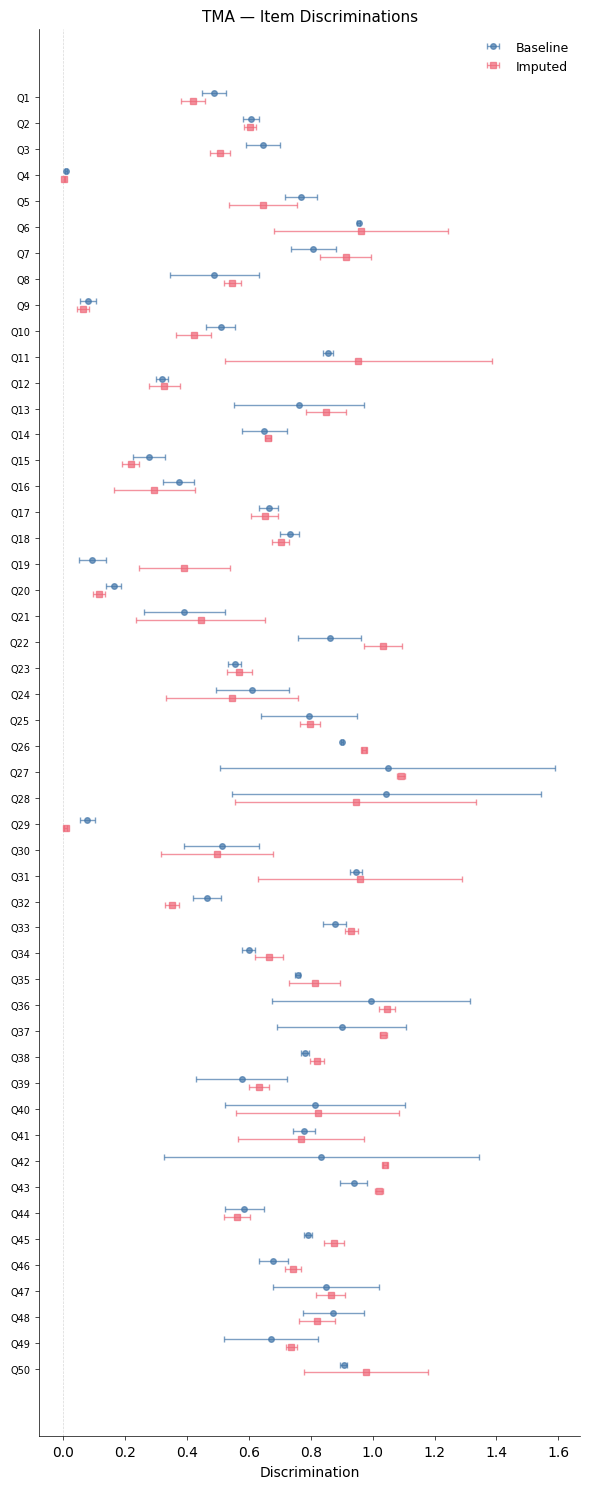

In [15]:
fig = plot_forest_discriminations(item_keys, model_baseline, model_imputed,
                                  title='TMA — Item Discriminations')
fig.savefig('discriminations.pdf', bbox_inches='tight', dpi=150)
plt.show()

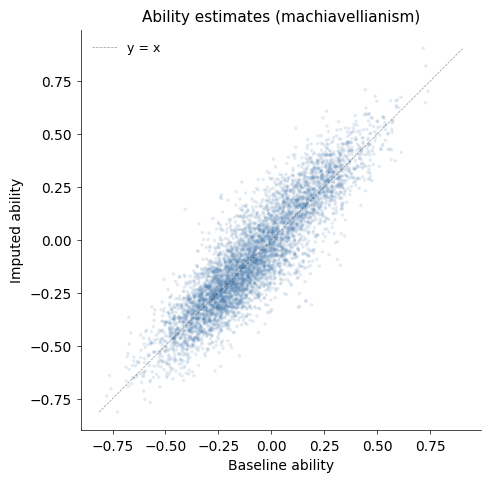

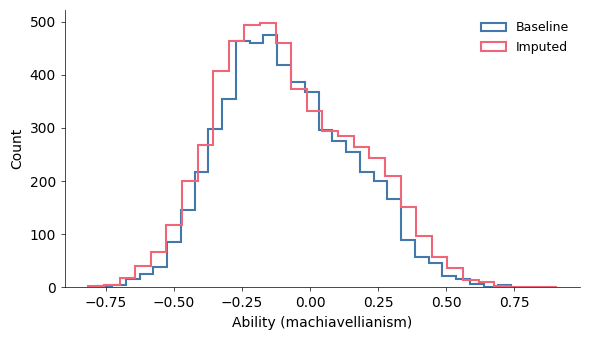

In [16]:
ab_base = np.array(model_baseline.calibrated_expectations['abilities']).flatten()
ab_imp = np.array(model_imputed.calibrated_expectations['abilities']).flatten()

fig = plot_ability_scatter(ab_base, ab_imp, label='machiavellianism')
fig.savefig('ability_scatter.pdf', bbox_inches='tight', dpi=150)
plt.show()

fig = plot_ability_distributions(ab_base, ab_imp, label='machiavellianism')
fig.savefig('ability_distributions.pdf', bbox_inches='tight', dpi=150)
plt.show()

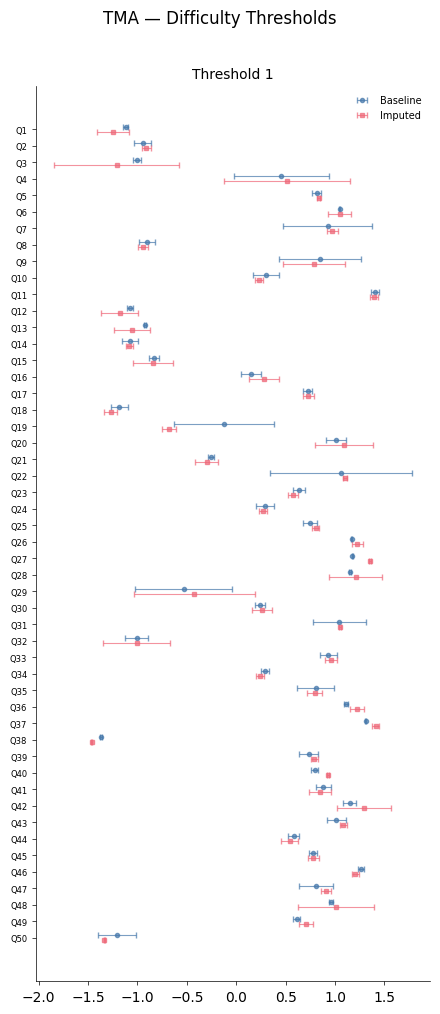

In [17]:
fig = plot_thresholds(item_keys, model_baseline, model_imputed,
                      title='TMA — Difficulty Thresholds')
fig.savefig('thresholds.pdf', bbox_inches='tight', dpi=150)
plt.show()

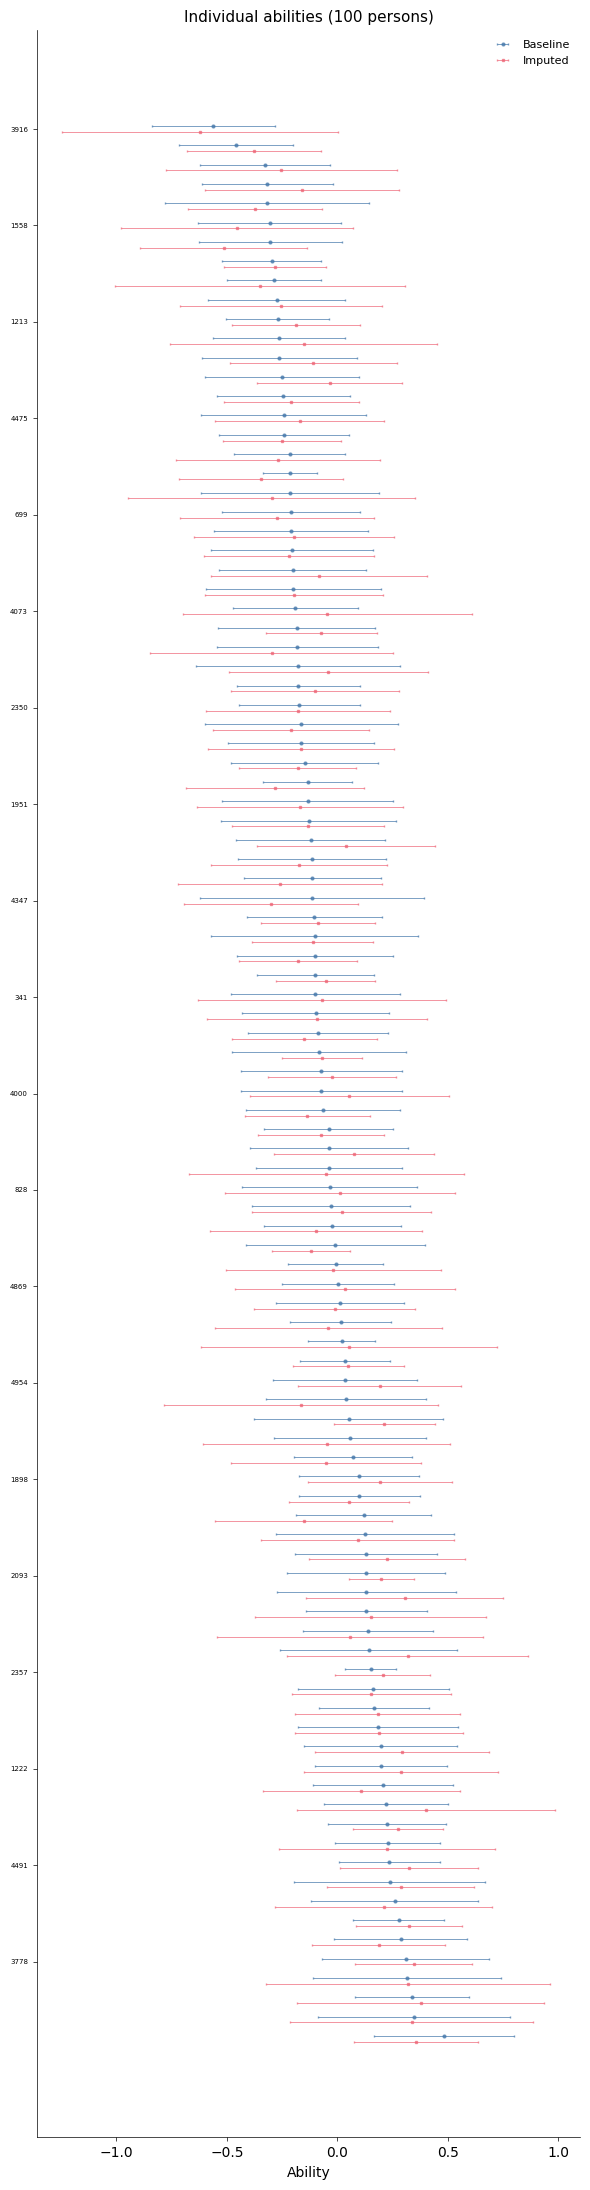

In [18]:
fig = plot_individual_abilities(item_keys, model_baseline, model_imputed)
fig.savefig('individual_abilities.pdf', bbox_inches='tight', dpi=150)
plt.show()

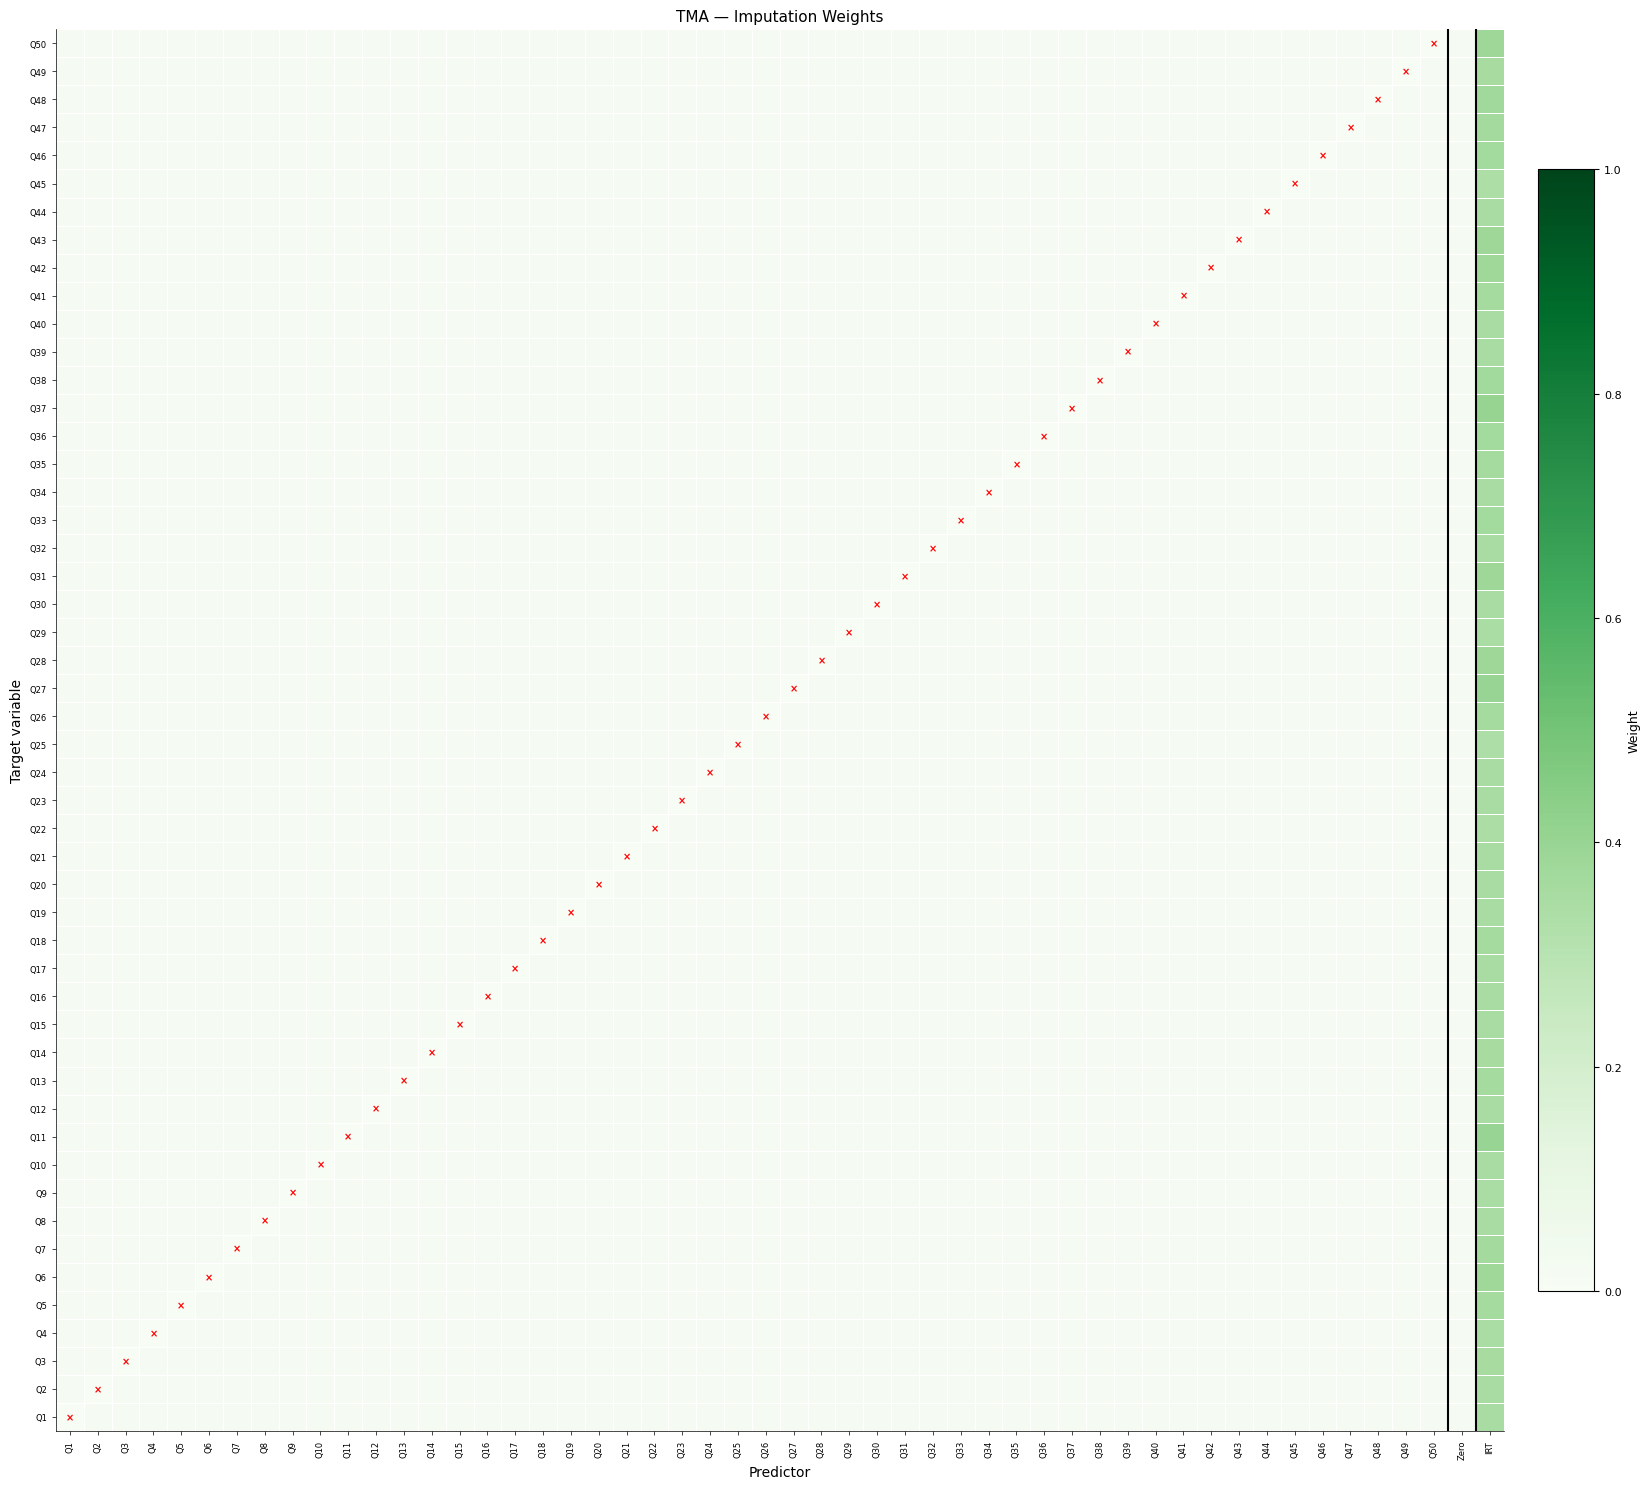

In [19]:
fig = plot_imputation_weights_pcolormesh(mice_loo, mixed_imputation, item_keys,
                                          title='TMA — Imputation Weights')
fig.savefig('imputation_weights.pdf', bbox_inches='tight', dpi=150)
plt.show()

## Summary

This notebook demonstrated fitting a single-dimensional Graded Response Model to the
Taylor Manifest Anxiety Scale (TMA) dataset (50 binary items, K=2). With binary responses,
the GRM reduces to a 2PL IRT model.

Two models were fitted:

1. **Baseline (ignorable missingness)**: Missing responses have their log-likelihood
   contributions zeroed out, assuming the missingness mechanism is ignorable.
2. **Mixed imputation (MICE + baseline IRT)**: A `MICEBayesianLOO` pairwise Bayesian
   model is blended with the baseline IRT model's marginalized predictions via per-item
   softmax weights over ELPD scores. Missing cells are analytically marginalized over
   the blended imputation PMF (Rao-Blackwellization).

The discrimination and ability estimates from both approaches can be compared to assess
the impact of the missingness handling strategy on parameter recovery.